## Dataset Selection and Data Collection

In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [ ]:
columns = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num',
    'marital-status', 'occupation', 'relationship', 'race', 'sex',
    'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income'
]

# Load local dataset files
train_df = pd.read_csv('adult/adult.data', header=None, names=columns, skipinitialspace=True)
test_df = pd.read_csv('adult/adult.test', header=None, names=columns, skiprows=1, skipinitialspace=True)

In [3]:
train_df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [4]:
train_df.shape, test_df.shape

((32561, 15), (16281, 15))

## Data Exploration and Preprocessing

### Checking

In [5]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education-num   32561 non-null  int64
 5   marital-status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital-gain    32561 non-null  int64
 11  capital-loss    32561 non-null  int64
 12  hours-per-week  32561 non-null  int64
 13  native-country  32561 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB


In [6]:
# Check for missing or invalid data
for col in train_df.columns:
    null_count = train_df[col].isna().sum()
    invalid_count = (train_df[col] == '?').sum()
    
    if null_count > 0 or invalid_count > 0:
        print(f"Column: '{col}'")
        
        if null_count > 0:
            null_pct = round(null_count / len(train_df) * 100, 2)
            print(f"  [MISSING DATA]: Found {null_count} standard null/NaN values ({null_pct}% of total records).")
            
        if invalid_count > 0:
            invalid_pct = round(invalid_count / len(train_df) * 100, 2)
            print(f"  [INVALID DATA]: Found {invalid_count} invalid '?' placeholder entries ({invalid_pct}% of total records).")

Column: 'workclass'
  [INVALID DATA]: Found 1836 invalid '?' placeholder entries (5.64% of total records).
Column: 'occupation'
  [INVALID DATA]: Found 1843 invalid '?' placeholder entries (5.66% of total records).
Column: 'native-country'
  [INVALID DATA]: Found 583 invalid '?' placeholder entries (1.79% of total records).


In [7]:
# Check for duplicate rows
print(f"Total duplicate rows: {train_df.duplicated().sum()}")

Total duplicate rows: 24


In [8]:
# Check Target Class Imbalance
print(train_df['income'].value_counts(normalize=True) * 100)

income
<=50K    75.919044
>50K     24.080956
Name: proportion, dtype: float64


### Cleaning

In [9]:
# Replace ? with missing values
train_df.replace('?', np.nan, inplace=True)
test_df.replace('?', np.nan, inplace=True)

# Remove rows with missing values and duplicate rows
train_df.dropna(inplace=True)
test_df.dropna(inplace=True)
train_df.drop_duplicates(inplace=True)
test_df.drop_duplicates(inplace=True)

In [10]:
train_df.shape

(30139, 15)

In [11]:
test_df.shape

(15055, 15)

### Encoding, Scaling, Normalization, Train-test Split

In [12]:
# Target Encoding
train_df['income'] = train_df['income'].astype(str).str.rstrip('.').str.strip().map({'<=50K': 0, '>50K': 1})
test_df['income'] = test_df['income'].astype(str).str.rstrip('.').str.strip().map({'<=50K': 0, '>50K': 1})

# Categorical Feature Encoding
train_encoded = pd.get_dummies(train_df, drop_first=True)
test_encoded = pd.get_dummies(test_df, drop_first=True)

# Define Features and Target
X_train = train_encoded.drop('income', axis=1)
y_train = train_encoded['income']

X_test = test_encoded.drop('income', axis=1)
y_test = test_encoded['income']

X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## Model Development

In [13]:
class KNNFromScratch:
    def __init__(self, k=15):
        self.k = k

    def fit(self, X, y):
        self.X_train = np.asarray(X)
        self.y_train = np.asarray(y)

    def predict_proba(self, X):
        probabilities = []

        for row in np.asarray(X):
            distances = np.sum((self.X_train - row) ** 2, axis=1)
            nearest_rows = np.argsort(distances)[:self.k]
            nearest_labels = self.y_train[nearest_rows]
            probabilities.append(np.mean(nearest_labels == 1))

        return np.array(probabilities)

    def predict(self, X):
        probabilities = self.predict_proba(X)
        return (probabilities >= 0.5).astype(int)

knn_scratch = KNNFromScratch(k=15)
knn_scratch.fit(X_train_scaled, y_train)
knn_scratch_probs = knn_scratch.predict_proba(X_test_scaled)
knn_scratch_preds = knn_scratch.predict(X_test_scaled)

In [14]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold


# Stratified folds preserve the class distribution
cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Hyperparameter tuning
searches = {
    "Decision Tree": GridSearchCV(
        DecisionTreeClassifier(random_state=42),
        {
            "max_depth": [5, 10, 15, None],
            "min_samples_split": [2, 10],
            "min_samples_leaf": [1, 5]
        },
        scoring="f1",
        cv=cv_strategy,
        n_jobs=-1
    ),
    "SVM": GridSearchCV(
        SVC(probability=True, random_state=42),
        {
            "C": [0.1, 1, 10],
            "kernel": ["linear", "rbf"]
        },
        scoring="f1",
        cv=cv_strategy,
        n_jobs=-1
    ),
    "MLP": GridSearchCV(
        MLPClassifier(
            early_stopping=True,
            max_iter=300,
            random_state=42
        ),
        {
            "hidden_layer_sizes": [(50,), (100,)],
            "alpha": [0.0001, 0.001],
            "learning_rate_init": [0.001, 0.01]
        },
        scoring="f1",
        cv=cv_strategy,
        n_jobs=-1
    )
}

best_models = {}

for name, search in searches.items():
    search.fit(X_train_scaled, y_train)
    best_models[name] = search.best_estimator_
    print(f"{name} best parameters: {search.best_params_}")
    print(f"{name} best validation F1: {search.best_score_:.4f}")

models = {
    "Custom KNN": knn_scratch,
    "Decision Tree": best_models["Decision Tree"],
    "SVM": best_models["SVM"],
    "Naive Bayes": GaussianNB(),
    "MLP": best_models["MLP"]
}

trained_models = {}
predictions = {}
probabilities = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model
    predictions[name] = model.predict(X_test_scaled)

    model_probabilities = model.predict_proba(X_test_scaled)
    probabilities[name] = (
        model_probabilities
        if model_probabilities.ndim == 1
        else model_probabilities[:, 1]
    )

Decision Tree best parameters: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 10}
Decision Tree best validation F1: 0.6740
SVM best parameters: {'C': 10, 'kernel': 'rbf'}
SVM best validation F1: 0.6564
MLP best parameters: {'alpha': 0.0001, 'hidden_layer_sizes': (100,), 'learning_rate_init': 0.01}
MLP best validation F1: 0.6797


### Model Implementation

KNN was implemented from scratch using Euclidean distance and the closest 15 rows. Decision Tree, SVM, Naive Bayes, and MLP were created with scikit-learn. The models are trained on the same scaled data so their results can be compared fairly.

In [15]:
# Compare training and testing accuracy
for name, model in trained_models.items():
    train_accuracy = (model.predict(X_train_scaled) == y_train).mean()
    test_accuracy = (predictions[name] == y_test).mean()
    print(name, "train accuracy:", round(train_accuracy, 3),
          "test accuracy:", round(test_accuracy, 3))

# Use cross-validation for the library models
for name, model in models.items():
    if name != "Custom KNN":
        scores = cross_val_score(model, X_train_scaled, y_train, cv=3)
        print(name, "cross-validation accuracy:", round(scores.mean(), 3))

Custom KNN train accuracy: 0.846 test accuracy: 0.827
Decision Tree train accuracy: 0.866 test accuracy: 0.857
SVM train accuracy: 0.878 test accuracy: 0.843
Naive Bayes train accuracy: 0.509 test accuracy: 0.504
MLP train accuracy: 0.867 test accuracy: 0.844
Decision Tree cross-validation accuracy: 0.85
SVM cross-validation accuracy: 0.843
Naive Bayes cross-validation accuracy: 0.442
MLP cross-validation accuracy: 0.848


=== CLASSIFIER EVALUATION COMPARISON ===
        Model  Accuracy  Precision  Recall  Specificity  F1-Score  Balanced Accuracy  ROC-AUC    MCC  Log Loss
   Custom KNN    0.8269     0.6740  0.5727       0.9097    0.6192             0.7412   0.8673 0.5110    0.5790
Decision Tree    0.8567     0.7721  0.5914       0.9431    0.6697             0.7672   0.9017 0.5886    0.4793
          SVM    0.8429     0.7154  0.5992       0.9223    0.6522             0.7608   0.8835 0.5553    0.3592
  Naive Bayes    0.5038     0.3258  0.9530       0.3574    0.4856             0.6552   0.7081 0.2972   15.8755
          MLP    0.8444     0.7120  0.6159       0.9188    0.6605             0.7674   0.8993 0.5627    0.3520


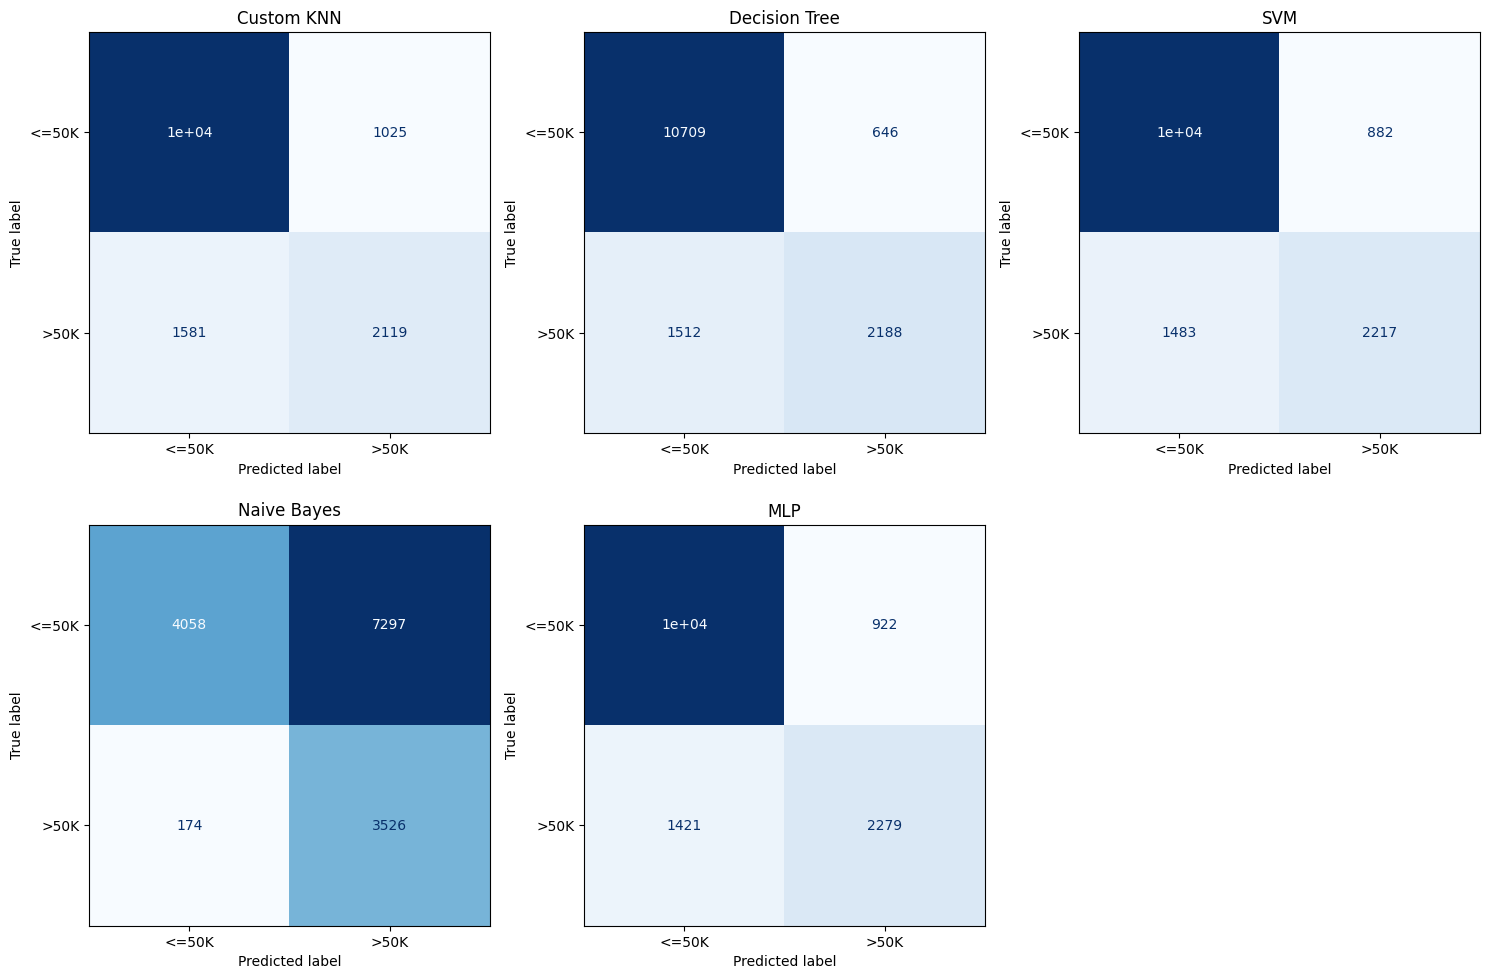

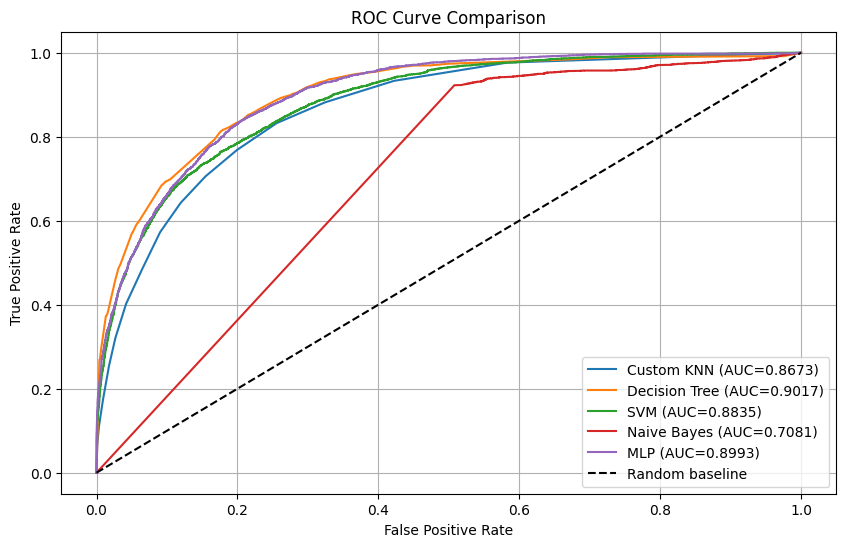

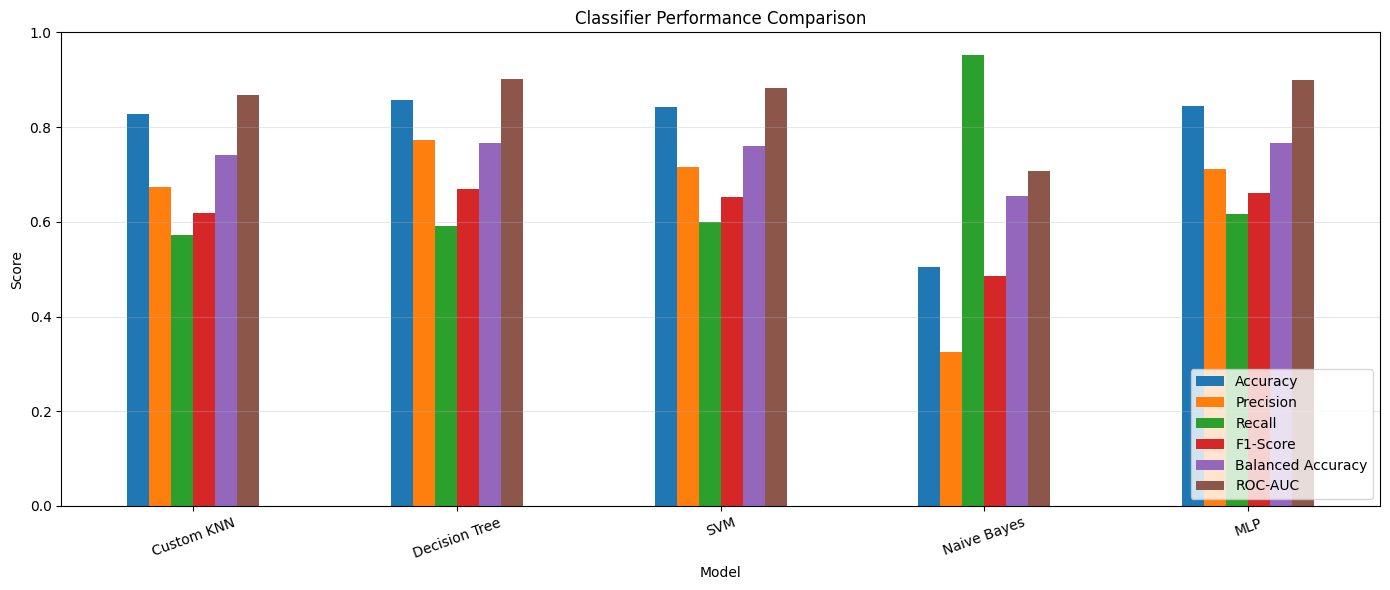

In [16]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, balanced_accuracy_score, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve, matthews_corrcoef, log_loss
)

results = []

for name, preds in predictions.items():
    cm = confusion_matrix(y_test, preds)
    tn, fp, fn, tp = cm.ravel()

    specificity = tn / (tn + fp) if (tn + fp) else 0

    results.append({
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, preds), 4),
        "Precision": round(
            precision_score(y_test, preds, zero_division=0), 4
        ),
        "Recall": round(
            recall_score(y_test, preds, zero_division=0), 4
        ),
        "Specificity": round(specificity, 4),
        "F1-Score": round(
            f1_score(y_test, preds, zero_division=0), 4
        ),
        "Balanced Accuracy": round(
            balanced_accuracy_score(y_test, preds), 4
        ),
        "ROC-AUC": round(
            roc_auc_score(y_test, probabilities[name]), 4
        ),
        "MCC": round(
            matthews_corrcoef(y_test, preds), 4
        ),
        "Log Loss": round(
            log_loss(y_test, probabilities[name]), 4
        )
    })

df_results = pd.DataFrame(results)

print("=== CLASSIFIER EVALUATION COMPARISON ===")
print(df_results.to_string(index=False))

# Confusion matrices
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for i, (name, preds) in enumerate(predictions.items()):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["<=50K", ">50K"]
    )
    disp.plot(ax=axes[i], cmap="Blues", colorbar=False)
    axes[i].set_title(name)

fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

# ROC curves
plt.figure(figsize=(10, 6))

for name in predictions:
    fpr, tpr, _ = roc_curve(y_test, probabilities[name])
    auc_value = df_results.loc[
        df_results["Model"] == name, "ROC-AUC"
    ].iloc[0]
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc_value})")

plt.plot([0, 1], [0, 1], "k--", label="Random baseline")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

# Metric comparison
metrics_to_plot = [
    "Accuracy", "Precision", "Recall",
    "F1-Score", "Balanced Accuracy", "ROC-AUC"
]

df_results.set_index("Model")[metrics_to_plot].plot(
    kind="bar",
    figsize=(14, 6),
    ylim=(0, 1),
    rot=20
)

plt.title("Classifier Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.grid(axis="y", alpha=0.3)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [17]:
overfitting_results = []

for name, model in trained_models.items():
    train_preds = model.predict(X_train_scaled)
    test_preds = predictions[name]

    train_acc = accuracy_score(y_train, train_preds)
    test_acc = accuracy_score(y_test, test_preds)

    overfitting_results.append({
        "Model": name,
        "Training Accuracy": round(train_acc, 4),
        "Test Accuracy": round(test_acc, 4),
        "Accuracy Gap": round(train_acc - test_acc, 4)
    })

overfitting_df = pd.DataFrame(overfitting_results)

print("=== OVERFITTING ANALYSIS ===")
print(overfitting_df.to_string(index=False))

=== OVERFITTING ANALYSIS ===
        Model  Training Accuracy  Test Accuracy  Accuracy Gap
   Custom KNN             0.8460         0.8269        0.0191
Decision Tree             0.8663         0.8567        0.0096
          SVM             0.8779         0.8429        0.0350
  Naive Bayes             0.5085         0.5038        0.0048
          MLP             0.8668         0.8444        0.0224


In [ ]:
from pathlib import Path
import json
import joblib

artifacts_dir = Path("artifacts")
artifacts_dir.mkdir(exist_ok=True)

# Export fitted library models. The custom KNN is exported separately below.
joblib.dump(
    {
        name: model
        for name, model in trained_models.items()
        if name != "Custom KNN"
    },
    artifacts_dir / "sklearn_models.joblib"
)

np.savez(
    artifacts_dir / "knn_data.npz",
    X_train=knn_scratch.X_train,
    y_train=knn_scratch.y_train
)

categorical_columns = [
    "workclass", "education", "marital-status", "occupation",
    "relationship", "race", "sex", "native-country"
]

metadata = {
    "feature_columns": X_train.columns.tolist(),
    "categorical_options": {
        column: sorted(train_df[column].unique().tolist())
        for column in categorical_columns
    },
    "knn_k": knn_scratch.k,
    "models": list(trained_models.keys())
}

with open(artifacts_dir / "metadata.json", "w", encoding="utf-8") as file:
    json.dump(metadata, file, indent=2)

joblib.dump(scaler, artifacts_dir / "scaler.joblib")
df_results.to_csv(artifacts_dir / "metrics.csv", index=False)
overfitting_df.to_csv(artifacts_dir / "overfitting.csv", index=False)

# Export confusion-matrix plot.
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()
for index, (name, preds) in enumerate(predictions.items()):
    ConfusionMatrixDisplay(
        confusion_matrix=confusion_matrix(y_test, preds),
        display_labels=["<=50K", ">50K"]
    ).plot(ax=axes[index], cmap="Blues", colorbar=False)
    axes[index].set_title(name)
fig.delaxes(axes[-1])
fig.tight_layout()
fig.savefig(artifacts_dir / "confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.close(fig)

# Export ROC plot.
fig, axis = plt.subplots(figsize=(10, 6))
for name in predictions:
    fpr, tpr, _ = roc_curve(y_test, probabilities[name])
    auc_value = df_results.loc[
        df_results["Model"] == name, "ROC-AUC"
    ].iloc[0]
    axis.plot(fpr, tpr, label=f"{name} (AUC={auc_value})")
axis.plot([0, 1], [0, 1], "k--", label="Random baseline")
axis.set_xlabel("False Positive Rate")
axis.set_ylabel("True Positive Rate")
axis.set_title("ROC Curve Comparison")
axis.legend(loc="lower right")
axis.grid(True)
fig.tight_layout()
fig.savefig(artifacts_dir / "roc_curves.png", dpi=150, bbox_inches="tight")
plt.close(fig)


with open(artifacts_dir / "metadata.json", "w", encoding="utf-8") as file:
    json.dump(metadata, file, indent=2)

# Export metric-comparison plot.
fig, axis = plt.subplots(figsize=(14, 6))
df_results.set_index("Model")[metrics_to_plot].plot(
    kind="bar", ylim=(0, 1), rot=20, ax=axis
)
axis.set_title("Classifier Performance Comparison")
axis.set_ylabel("Score")
axis.set_xlabel("Model")
axis.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(artifacts_dir / "metric_comparison.png", dpi=150, bbox_inches="tight")
plt.close(fig)

print(f"Exported models, metadata, metrics, and plots to {artifacts_dir.resolve()}")

Exported models, metadata, metrics, and plots to /Users/subhakarpant/data_mining/artifacts
